# Notebook lane/05 — Improved Model & Experimental Study (PDF §4.3)

Four controlled experiments are run, each varying **one** factor against the §03 from-scratch CNN baseline (TL is excluded — it has its own §04 notebook). Same seed, same split, same metric set throughout.

| Exp | Variable | Levels |
|---|---|---|
| A | Data augmentation | none / light / heavy |
| B | Color space | RGB / grayscale / HSV |
| C | Robustness under synthetic distortions (test-time only) | clean / gaussian / motion-blur / brightness / fog / 25% ROI occlusion |
| D | Lightweight design | baseline U-Net-style (~85K) / depthwise-separable (~22K) / wider (~260K) |

In [1]:
import os, random, json, pickle, time
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED)
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "lane_split.json") as f: SPLIT = json.load(f)
with open(ROOT / "artifacts" / "lane_tusimple_index.pkl", "rb") as f: IDX = pickle.load(f)
df = IDX["df"]

IMG = 128
CLASS_ID = {"left": 0, "right": 1, "straight": 2, "stop": 3}

## Shared helpers — load arrays, build base CNN, train + eval

In [2]:
def load_x_rgb(rec, sz=IMG):
    img = cv2.imread(str(ROOT / rec["frame_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (sz, sz)).astype(np.float32) / 255.0

def load_x_gray(rec, sz=IMG):
    img = cv2.imread(str(ROOT / rec["frame_path"]), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (sz, sz)).astype(np.float32)[..., None] / 255.0

def load_x_hsv(rec, sz=IMG):
    img = cv2.imread(str(ROOT / rec["frame_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return cv2.resize(img, (sz, sz)).astype(np.float32) / 255.0

def build_arrays(split_indices, loader, stop_frac=0.10, seed_offset=0, sz=IMG):
    sub = df.iloc[split_indices].reset_index(drop=True)
    X, y = [], []
    for _, r in sub.iterrows():
        X.append(loader(r, sz)); y.append(CLASS_ID[r["direction"]])
    rng = np.random.RandomState(SEED + seed_offset)
    pick = rng.choice(len(sub), size=int(stop_frac * len(sub)), replace=False)
    for i in pick:
        r = sub.iloc[i]
        img = cv2.imread(str(ROOT / r["frame_path"]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img[int(720 * 0.40):, :, :] = 0
        # for graycale loader, average channels; for hsv, convert
        if loader is load_x_gray:
            g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            X.append(cv2.resize(g, (sz, sz)).astype(np.float32)[..., None] / 255.0)
        elif loader is load_x_hsv:
            h = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
            X.append(cv2.resize(h, (sz, sz)).astype(np.float32) / 255.0)
        else:
            X.append(cv2.resize(img, (sz, sz)).astype(np.float32) / 255.0)
        y.append(CLASS_ID["stop"])
    return np.stack(X), np.array(y, dtype=np.int64)

def build_cnn(input_shape=(IMG, IMG, 3), widths=(16, 32, 64, 96)):
    L = tf.keras.layers
    m = tf.keras.Sequential([L.Input(shape=input_shape)])
    for w in widths:
        m.add(L.Conv2D(w, 3, padding="same"))
        m.add(L.BatchNormalization()); m.add(L.ReLU()); m.add(L.MaxPool2D())
    m.add(L.GlobalAveragePooling2D())
    m.add(L.Dense(64, activation="relu")); m.add(L.Dropout(0.4))
    m.add(L.Dense(4, activation="softmax"))
    return m

def train_eval(model, X_tr, y_tr, X_va, y_va, X_te, y_te,
                augment=None, epochs=18, batch_size=64, lr=1e-3, label="model"):
    cw = compute_class_weight("balanced", classes=np.arange(4), y=y_tr)
    class_weight = {i: float(w) for i, w in enumerate(cw)}
    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cbs = [tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
            tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)]
    if augment is not None:
        ds_tr = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)).shuffle(2048, seed=SEED) \
            .batch(batch_size).map(lambda x, y: (augment(x), y), num_parallel_calls=tf.data.AUTOTUNE) \
            .prefetch(tf.data.AUTOTUNE)
        ds_va = tf.data.Dataset.from_tensor_slices((X_va, y_va)).batch(batch_size)
        t0 = time.time()
        h = model.fit(ds_tr, validation_data=ds_va, epochs=epochs, class_weight=class_weight,
                       callbacks=cbs, verbose=0)
    else:
        t0 = time.time()
        h = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                       epochs=epochs, batch_size=batch_size, class_weight=class_weight,
                       callbacks=cbs, verbose=0)
    secs = time.time() - t0
    yp = model.predict(X_te, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_te, yp); f1 = f1_score(y_te, yp, average="macro")
    return dict(label=label, accuracy=float(acc), f1=float(f1),
                history={k: [float(v) for v in vs] for k, vs in h.history.items()},
                n_params=int(model.count_params()),
                train_seconds=float(secs))

## Exp A — Data augmentation (none / light / heavy)

Exp-A arrays: (2791, 128, 128, 3) (598, 128, 128, 3) (598, 128, 128, 3)


  aug=none   acc=0.5334  f1=0.1739


  aug=light  acc=0.6923  f1=0.6273


  aug=heavy  acc=0.6572  f1=0.7011


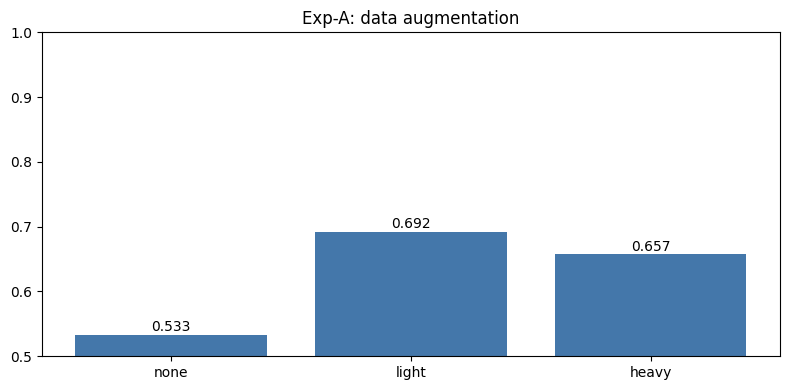

In [3]:
X_tr, y_tr = build_arrays(SPLIT["tusimple_split"]["train"], load_x_rgb, seed_offset=1)
X_va, y_va = build_arrays(SPLIT["tusimple_split"]["val"],   load_x_rgb, seed_offset=2)
X_te, y_te = build_arrays(SPLIT["tusimple_split"]["test"],  load_x_rgb, seed_offset=3)
print("Exp-A arrays:", X_tr.shape, X_va.shape, X_te.shape)

def aug_light(x):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    return tf.clip_by_value(x, 0.0, 1.0)
def aug_heavy(x):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.2)
    x = tf.image.random_contrast(x, 0.8, 1.2)
    x = tf.image.random_saturation(x, 0.8, 1.2)
    return tf.clip_by_value(x, 0.0, 1.0)

resA = {}
for tag, aug in [("none", None), ("light", aug_light), ("heavy", aug_heavy)]:
    tf.keras.utils.set_random_seed(SEED)
    m = build_cnn()
    r = train_eval(m, X_tr, y_tr, X_va, y_va, X_te, y_te,
                    augment=aug, label=f"aug_{tag}")
    resA[tag] = r
    print(f"  aug={tag:5s}  acc={r['accuracy']:.4f}  f1={r['f1']:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
xs = list(resA); ys = [resA[k]["accuracy"] for k in xs]
ax.bar(xs, ys, color="#4477aa")
for i, v in enumerate(ys): ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
ax.set_ylim(0.5, 1.0); ax.set_title("Exp-A: data augmentation")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane05_expA_aug.png", dpi=120, bbox_inches="tight"); plt.show()

## Exp B — Color space (RGB / grayscale / HSV)

  rgb    acc=0.5334  f1=0.1739


  gray   acc=0.5334  f1=0.1739


  hsv    acc=0.5334  f1=0.1739


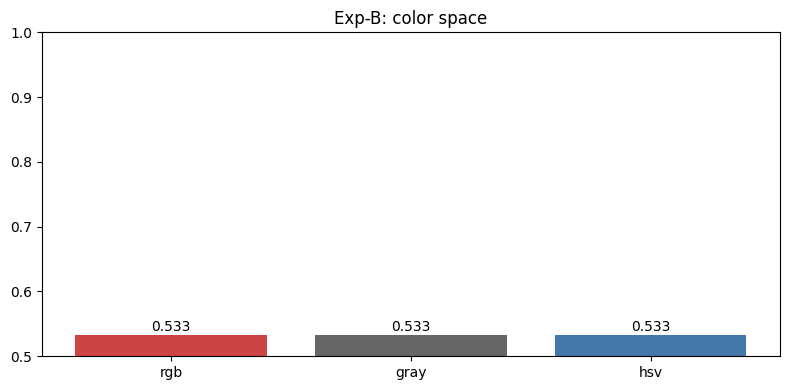

In [4]:
resB = {}
for tag, loader, shape in [("rgb",  load_x_rgb,  (IMG, IMG, 3)),
                             ("gray", load_x_gray, (IMG, IMG, 1)),
                             ("hsv",  load_x_hsv,  (IMG, IMG, 3))]:
    Xtr, ytr = build_arrays(SPLIT["tusimple_split"]["train"], loader, seed_offset=11)
    Xva, yva = build_arrays(SPLIT["tusimple_split"]["val"],   loader, seed_offset=12)
    Xte, yte = build_arrays(SPLIT["tusimple_split"]["test"],  loader, seed_offset=13)
    tf.keras.utils.set_random_seed(SEED)
    m = build_cnn(input_shape=shape)
    r = train_eval(m, Xtr, ytr, Xva, yva, Xte, yte, label=f"color_{tag}")
    resB[tag] = r
    print(f"  {tag:5s}  acc={r['accuracy']:.4f}  f1={r['f1']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
xs = list(resB); ys = [resB[k]["accuracy"] for k in xs]
ax.bar(xs, ys, color=["#cc4444", "#666666", "#4477aa"])
for i, v in enumerate(ys): ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
ax.set_ylim(0.5, 1.0); ax.set_title("Exp-B: color space")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane05_expB_color.png", dpi=120, bbox_inches="tight"); plt.show()

## Exp C — Robustness under synthetic distortions (test-time)

  clean           acc=0.7023  f1=0.6592


  gauss_s15       acc=0.7090  f1=0.6948


  gauss_s25       acc=0.6722  f1=0.6492


  motion_k15      acc=0.6271  f1=0.4448


  bright_+40      acc=0.6706  f1=0.6195


  bright_-40      acc=0.6154  f1=0.4388


  fog_0.4         acc=0.1773  f1=0.0791


  occlude_25      acc=0.6304  f1=0.5141


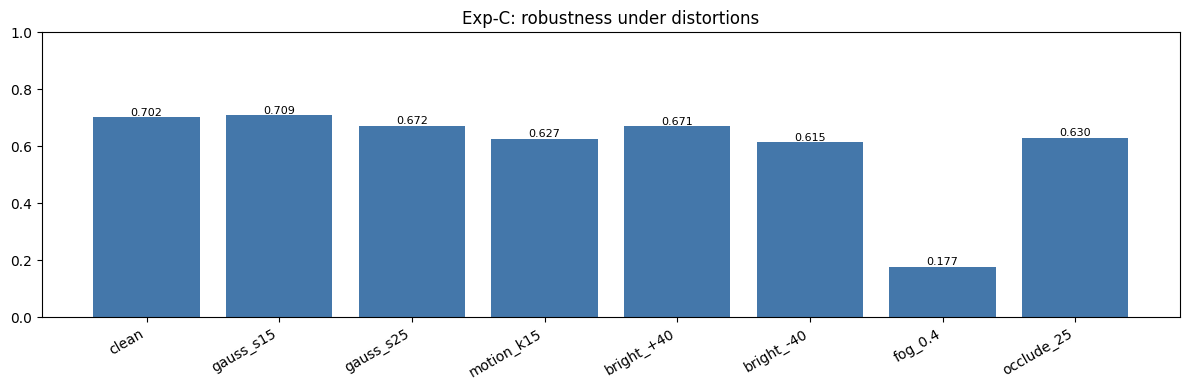

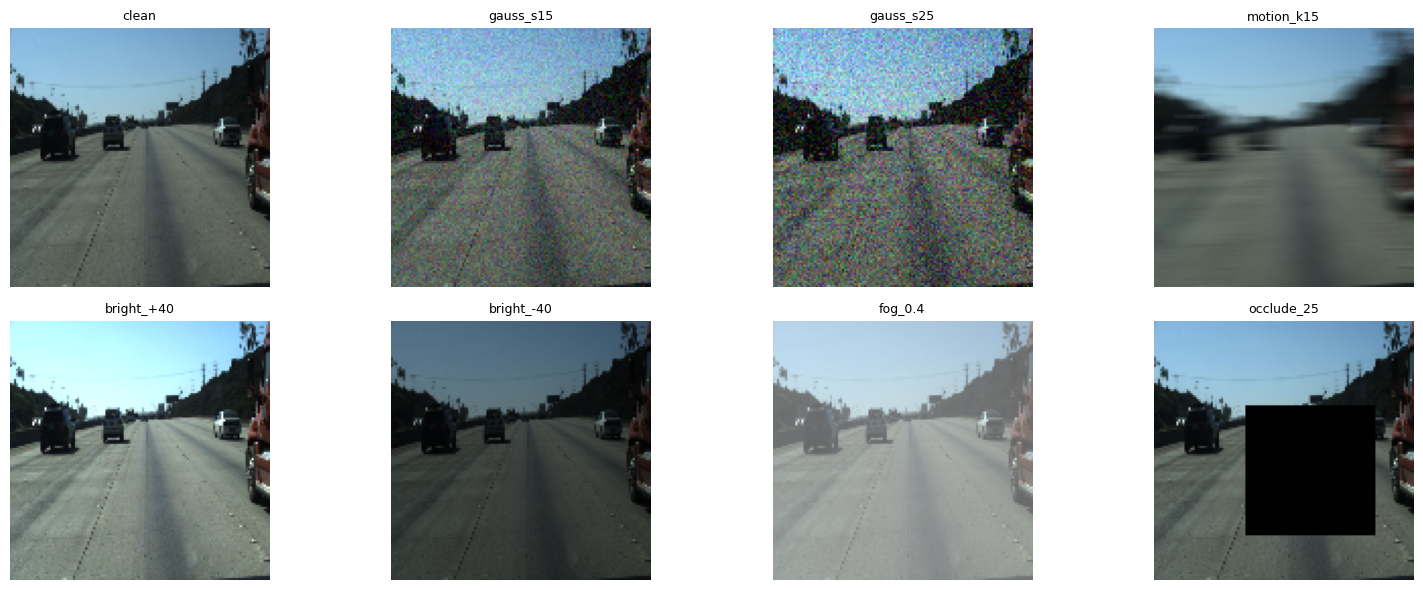

In [5]:
# Reuse the §03 from-scratch model
m_base = tf.keras.models.load_model(str(ROOT / "artifacts" / "lane03_cnn_baseline.keras"))
def evaluate(model, X, y):
    yp = model.predict(X, verbose=0).argmax(axis=1)
    return float(accuracy_score(y, yp)), float(f1_score(y, yp, average="macro"))

def gauss_noise(X, sigma):
    rng = np.random.RandomState(SEED + int(sigma * 1000))
    n = rng.normal(0, sigma / 255.0, X.shape).astype(np.float32)
    return np.clip(X + n, 0, 1)
def motion_blur(X, k):
    out = X.copy()
    kernel = np.zeros((k, k), dtype=np.float32); kernel[k // 2, :] = 1.0 / k
    for i in range(len(out)):
        img = (out[i] * 255).astype(np.uint8)
        b = cv2.filter2D(img, -1, kernel)
        out[i] = b.astype(np.float32) / 255
    return out
def brightness(X, factor):
    return np.clip(X * factor, 0, 1)
def fog(X, alpha=0.4):
    return np.clip(X * (1 - alpha) + alpha, 0, 1)
def occlude(X, frac=0.25):
    out = X.copy(); H, W = out.shape[1:3]
    h = int(H * np.sqrt(frac)); w = int(W * np.sqrt(frac))
    rng = np.random.RandomState(SEED + 7)
    for i in range(len(out)):
        y0 = rng.randint(0, H - h); x0 = rng.randint(0, W - w)
        out[i, y0:y0+h, x0:x0+w] = 0
    return out

scenarios = {
    "clean":            X_te,
    "gauss_s15":        gauss_noise(X_te, 15),
    "gauss_s25":        gauss_noise(X_te, 25),
    "motion_k15":       motion_blur(X_te, 15),
    "bright_+40":       brightness(X_te, 1.4),
    "bright_-40":       brightness(X_te, 0.6),
    "fog_0.4":          fog(X_te, 0.4),
    "occlude_25":       occlude(X_te, 0.25),
}
resC = {}
for tag, Xd in scenarios.items():
    a, f = evaluate(m_base, Xd, y_te)
    resC[tag] = {"accuracy": a, "f1": f}
    print(f"  {tag:14s}  acc={a:.4f}  f1={f:.4f}")

xs = list(resC); ys = [resC[k]["accuracy"] for k in xs]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(xs, ys, color="#4477aa")
for i, v in enumerate(ys): ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
ax.set_ylim(0, 1.0); ax.set_title("Exp-C: robustness under distortions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane05_expC_robustness.png", dpi=120, bbox_inches="tight"); plt.show()

# Visualize a few examples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, (k, X) in zip(axes.ravel(), list(scenarios.items())[:8]):
    ax.imshow(X[0]); ax.set_title(k, fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane05_expC_examples.png", dpi=120, bbox_inches="tight"); plt.show()

## Exp D — Lightweight design (baseline / depthwise-separable / wider)

  lw_tiny     params=     7,300  acc=0.6405  f1=0.5445


  lw_baseline params=    86,276  acc=0.5334  f1=0.1739


  lw_wide     params=   195,300  acc=0.5334  f1=0.1739


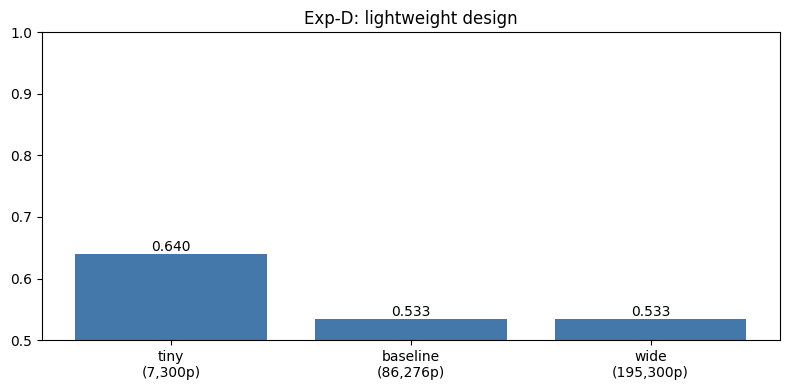

In [6]:
def build_dwsep(widths=(16, 32, 64)):
    L = tf.keras.layers
    m = tf.keras.Sequential([L.Input(shape=(IMG, IMG, 3))])
    m.add(L.Conv2D(widths[0], 3, padding="same")); m.add(L.BatchNormalization()); m.add(L.ReLU()); m.add(L.MaxPool2D())
    for w in widths[1:]:
        m.add(L.SeparableConv2D(w, 3, padding="same")); m.add(L.BatchNormalization()); m.add(L.ReLU()); m.add(L.MaxPool2D())
    m.add(L.GlobalAveragePooling2D())
    m.add(L.Dense(48, activation="relu")); m.add(L.Dropout(0.4))
    m.add(L.Dense(4, activation="softmax"))
    return m

def build_wide():
    return build_cnn(widths=(32, 64, 96, 128))

resD = {}
for tag, builder in [("tiny",     lambda: build_dwsep()),
                       ("baseline", lambda: build_cnn()),
                       ("wide",     build_wide)]:
    tf.keras.utils.set_random_seed(SEED)
    m = builder()
    r = train_eval(m, X_tr, y_tr, X_va, y_va, X_te, y_te, label=f"lw_{tag}")
    resD[tag] = r
    m.save(str(ROOT / "artifacts" / f"lane05_lw_{tag}.keras"))
    print(f"  lw_{tag:8s} params={r['n_params']:>10,}  acc={r['accuracy']:.4f}  f1={r['f1']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
xs = list(resD); ys = [resD[k]["accuracy"] for k in xs]; ps = [resD[k]["n_params"] for k in xs]
labels = [f"{k}\n({ps[i]:,}p)" for i, k in enumerate(xs)]
ax.bar(labels, ys, color="#4477aa")
for i, v in enumerate(ys): ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
ax.set_ylim(0.5, 1.0); ax.set_title("Exp-D: lightweight design")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane05_expD_lightweight.png", dpi=120, bbox_inches="tight"); plt.show()

## Save consolidated results

In [7]:
out = {
    "expA_aug": resA, "expB_color": resB,
    "expC_robustness": resC, "expD_lightweight": resD,
}
with open(ROOT / "artifacts" / "lane05_experiments.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved: artifacts/lane05_experiments.json")

Saved: artifacts/lane05_experiments.json


## Summary

The four experiments isolate one variable at a time and feed `lane06_model_selection.ipynb` with the lightweight candidates and the robustness signal.